### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import statsmodels
import prophet
import sklearn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/test.csv')

### Data Overview

In [4]:
train_df.shape

(913000, 4)

In [5]:
train_df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
test_df.head()

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [6]:
train_df['date'] = pd.to_datetime(train_df['date'])

### EDA

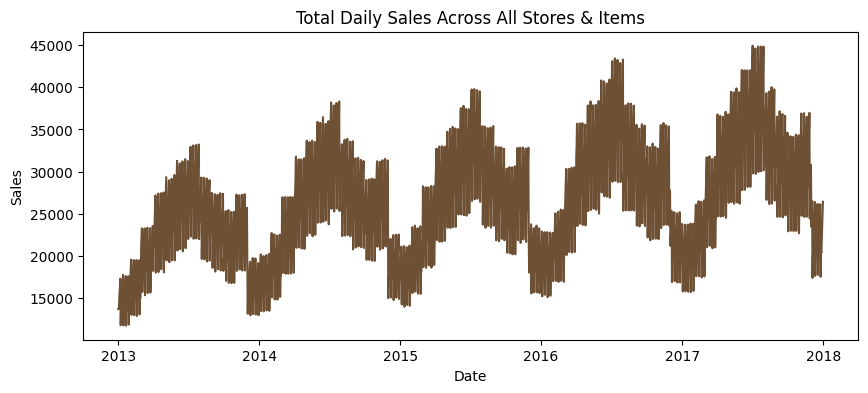

In [7]:
daily_sales = train_df.groupby('date')['sales'].sum().reset_index()
# Group all data from the same day/date together
# Then sum the sales across all stores and all items for that day into a single number

plt.figure(figsize=(10,4))
plt.plot(daily_sales['date'], daily_sales['sales'], color='#6E5034')
plt.title('Total Daily Sales Across All Stores & Items')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

*  Clear annual growth trend: each year’s peak is higher than the previous year’s, increasing from around 33,000 in 2013 to about 45,000 in 2017.
*  Strong seasonality: the same pattern repeats every year, which sales are lower at the beginning of the year, rise sharply during the summer and decline again toward the end of the year. This creates a  consistent one-year cycle.
*  Short-term zigzag fluctuations: these may reflect a day-of-week effect, such as higher sales on weekends than on weekdays. We can further decompose the data later to verify whether this pattern is indeed driven by weekly seasonality.

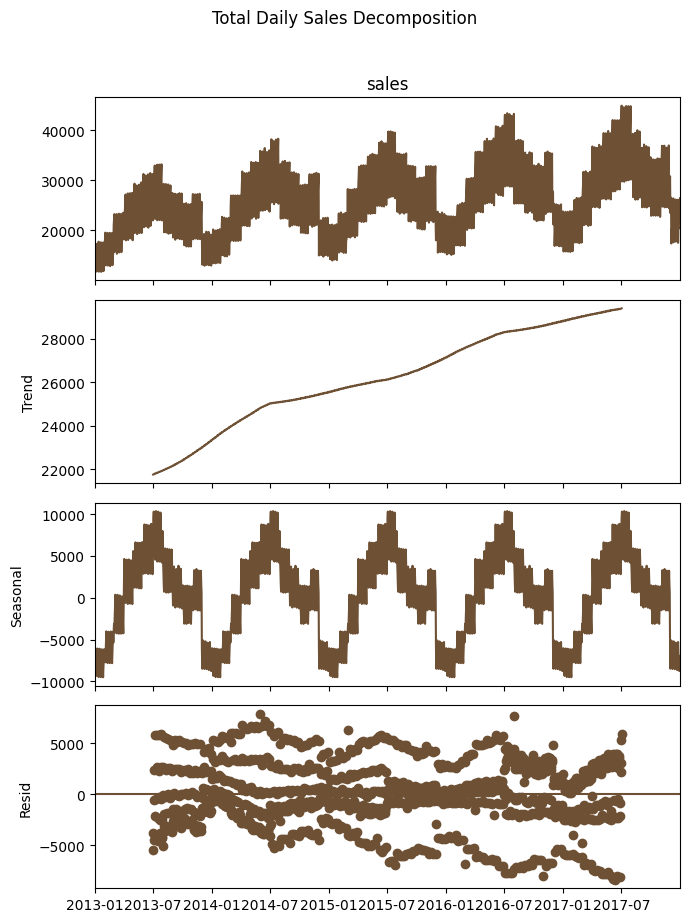

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_sales.set_index('date')['sales'], model='additive', period=365)
fig = decomposition.plot()

fig.set_size_inches(7, 9)

line_color = '#6E5034'

for ax in fig.axes:
    for line in ax.lines:
        line.set_color(line_color)

plt.suptitle('Total Daily Sales Decomposition', y=1.02)
plt.tight_layout()
plt.show()

*   Trend: after removing short-term fluctuations, we focus only on the overall direction. The trend line rises steadily from 22,000 in 2013 to about 29,000 in 2017. This suggests that the business itself is growing over time. The increase is not caused by seasonality.
*   Seasonal: this represents the fixed pattern that repeats every year. The values fluctuate regularly between roughly -10,000 and +10,000, with one cycle each year. This suggests that sales are naturally higher in the summer and lower in the winter. It is a predictable seasonal pattern rather than random variation.
*   Resid/residual: after removing both the trend and seasonal components, this is the variation that remains unexplained. The residuals appear to stay roughly between -5,000 and +5,000, without getting wider or narrower over time. Overall, they look relatively stable, with no obvious unusual pattern.

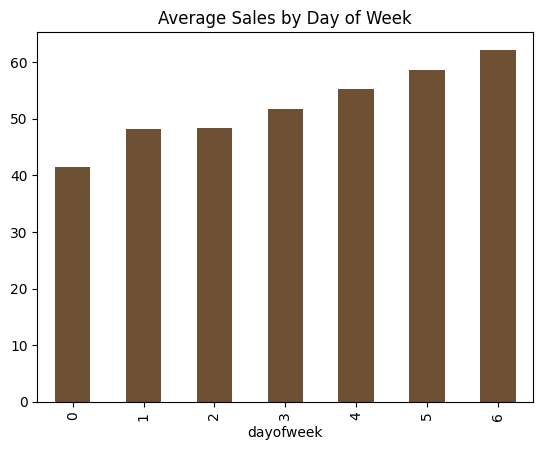

In [9]:
train_df['dayofweek'] = train_df['date'].dt.dayofweek
train_df.groupby('dayofweek')['sales'].mean().plot(kind='bar', color='#6E5034')
plt.title('Average Sales by Day of Week')
plt.show()

Day-of-week effect:
*   Monday (0) has the lowest sales, at around 41.
*   Sales increase steadily from Monday through Sunday, with Friday, Saturday and Sunday (4, 5, 6) showing noticeably higher sales.
*   Sunday (6) has the highest sales of the week, at around 62 — nearly 50% higher than Monday.

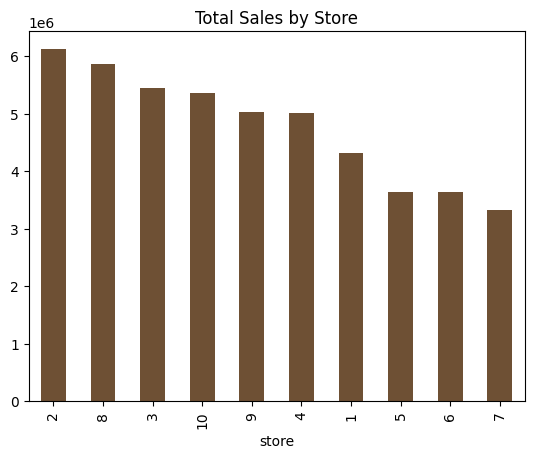

In [10]:
# difference of sales between stores
store_sales = train_df.groupby('store')['sales'].sum().sort_values(ascending=False)
store_sales.plot(kind='bar', color='#6E5034')
plt.title('Total Sales by Store')
plt.show()

Store effect:
*  Store 2 has the highest sales, while Store 7 has the lowest.
*  There are noticeable differences across stores, but the gaps are not large enough to justify building a separate model for each store.
*  Instead, store should be included as a feature in the model so it can account for store-level differences.

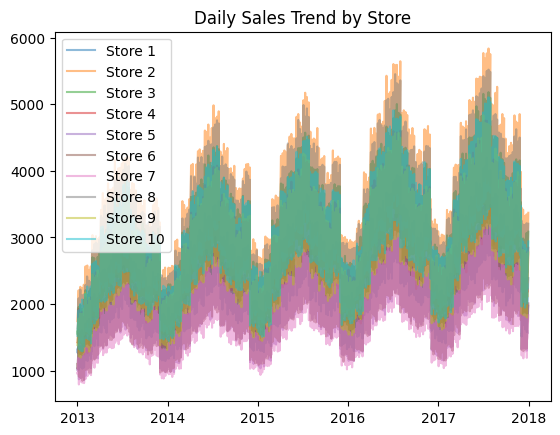

In [11]:
# does each store follows a consistent time trend
for store_id in train_df['store'].unique():
    store_daily = train_df[train_df['store']==store_id].groupby('date')['sales'].sum()
    plt.plot(store_daily.index, store_daily.values, alpha=0.5, label=f'Store {store_id}')
plt.legend()
plt.title('Daily Sales Trend by Store')
plt.show()

*  The curves for all 10 stores are nearly identical in shape, showing the same seasonality and overall growth trend, with the main difference being their sales levels (magnitude).
*  This suggests that the seasonal patterns and time trends are shared across stores, so there is no need to model seasonality separately for each store.

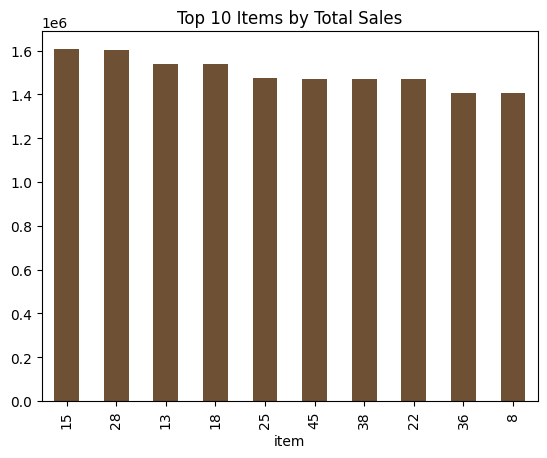

In [12]:
# difference of sales between items
item_sales = train_df.groupby('item')['sales'].sum().sort_values(ascending=False)
item_sales.head(10).plot(kind='bar', color='#6E5034')
plt.title('Top 10 Items by Total Sales')
plt.show()

*   The top 10 items have relatively similar sales levels, with no clear 80/20 concentration effect.
*   This suggests that sales are fairly evenly distributed across items, rather than being driven primarily by a small number of best-selling products.

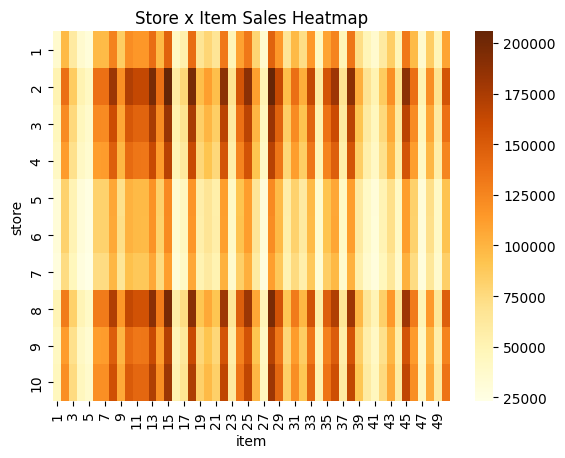

In [13]:
# heatmap
pivot = train_df.pivot_table(index='store', columns='item', values='sales', aggfunc='sum')
import seaborn as sns
sns.heatmap(pivot, cmap='YlOrBr')
plt.title('Store x Item Sales Heatmap')
plt.show()

*   There is clear horizontal banding: the same items show very similar sales patterns across different stores. For example, Items 15 and 28 consistently have higher sales across nearly all stores.
*   This suggests that item popularity is largely consistent across locations, with no strong evidence of distinct regional preferences.
*   The main differences are driven by the overall sales level of each store, rather than differences in which items customers prefer.


###  Model

#### Baseline 1：Naive Forecast

In [14]:
# use sales from the same day last year as this year's prediction

# complete store x item x date dataset
df = train_df.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store', 'item', 'date'])

# create a same-period-last-year feature by shifting 365 days
df['sales_last_year'] = df.groupby(['store', 'item'])['sales'].shift(365)

# remove the first year, which has no previous-year data
baseline_df = df.dropna(subset=['sales_last_year'])

# prediction errors
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

nonzero = baseline_df[baseline_df['sales'] != 0]

mape = mean_absolute_percentage_error(nonzero['sales'], nonzero['sales_last_year'])
rmse = np.sqrt(mean_squared_error(nonzero['sales'], nonzero['sales_last_year']))

print(f'Naive (Last Year) Baseline — MAPE: {mape:.2%}, RMSE: {rmse:.2f}')

Naive (Last Year) Baseline — MAPE: 23.42%, RMSE: 14.96


#### Model 2: Prophet

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


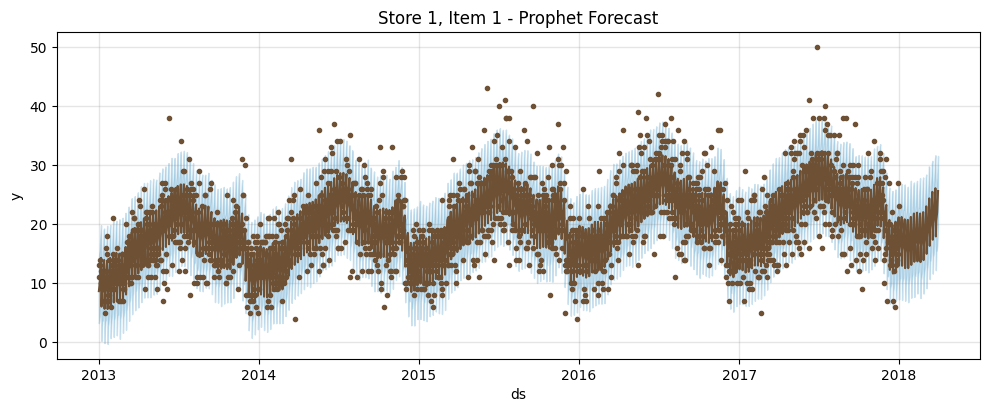

In [15]:
from prophet import Prophet
# time series forecasting tool by Meta
# Sales = Trend + Seasonality + Holiday Effects + Error

# Prophet requires the column names to be ds (date) and y (value)
sample = train_df[(train_df['store']==1) & (train_df['item']==1)][['date','sales']].copy()
sample.columns = ['ds', 'y']

model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(sample)

# Forecast the next 3 months (approximately 90 days)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

fig1 = model.plot(forecast, figsize=(10, 4))
for line in fig1.axes[0].get_lines():
    line.set_color('#6E5034')
plt.title('Store 1, Item 1 - Prophet Forecast')
plt.show()

*  dots = actual daily sales, line = sales predicted by Prophet
*  light blue area = the uncertainty interval, which represents how uncertain the model is about its predictions.
*  The  line captures the overall wave-like pattern well, including the long-term growth trend and seasonal fluctuations. Although the actual daily sales are scattered, most points remain reasonably close to the predicted range. This suggests that the model successfully captures the underlying pattern, while some day-to-day random variation is naturally difficult to predict with complete accuracy.

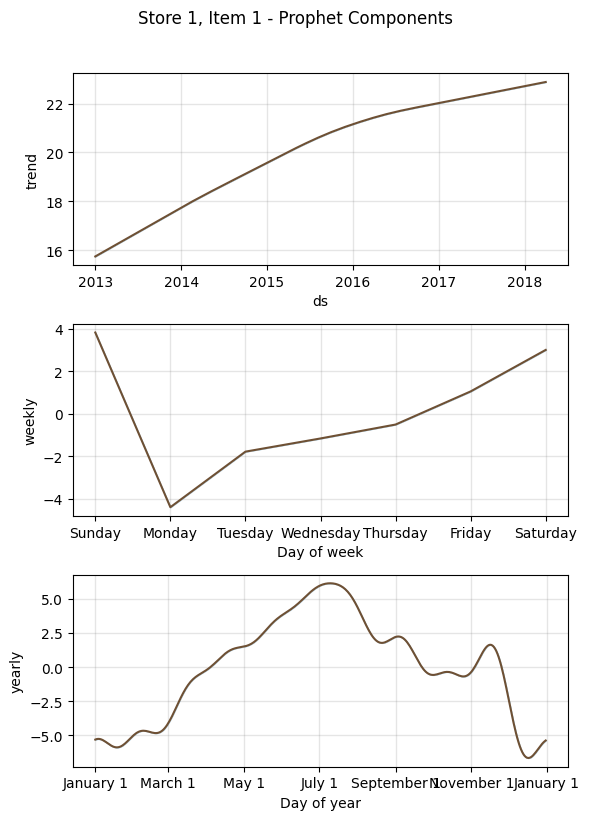

In [16]:
# trend/seasonality
fig2 = model.plot_components(forecast, figsize=(6, 8))

single_color = '#6E5034'

for ax in fig2.axes:
    for line in ax.lines:
        line.set_color(single_color)

plt.suptitle('Store 1, Item 1 - Prophet Components', y=1.02)
plt.tight_layout()
plt.show()

*   The sales for the Store 1, Item 1 combination show a clear linear upward trend, consistent with the overall trend observed in the earlier EDA. This suggests that sales for this item are growing over time.
*   The weekly pattern is consistent with the earlier “Average Sales by Day of Week” analysis.
*   Sales are highest in July and lowest around early January and late December, matching the annual seasonal pattern observed earlier: higher sales in summer and lower sales in winter.

In [17]:
# train
import logging

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

train_df['date'] = pd.to_datetime(train_df['date'])
cutoff_date = train_df['date'].max() - pd.Timedelta(days=90)

results = []

for store_id in train_df['store'].unique():
    for item_id in train_df['item'].unique():
        subset = train_df[(train_df['store']==store_id) & (train_df['item']==item_id)][['date','sales']].copy()
        subset.columns = ['ds', 'y']

        train_part = subset[subset['ds'] <= cutoff_date]
        test_part = subset[subset['ds'] > cutoff_date]

        model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model.fit(train_part)

        future = model.make_future_dataframe(periods=90)
        forecast = model.predict(future)

        pred = forecast[forecast['ds'] > cutoff_date][['ds','yhat']]
        merged = test_part.merge(pred, on='ds')
        merged['store'] = store_id
        merged['item'] = item_id

        results.append(merged)

final_results = pd.concat(results)

In [18]:
# evaluate
nonzero = final_results[final_results['y'] != 0]

mape = mean_absolute_percentage_error(nonzero['y'], nonzero['yhat'])
rmse = np.sqrt(mean_squared_error(nonzero['y'], nonzero['yhat']))

print(f'Prophet (Full 500 combinations) — MAPE: {mape:.2%}, RMSE: {rmse:.2f}')

Prophet (Full 500 combinations) — MAPE: 14.15%, RMSE: 8.26


#### Model 3: XGBoost

In [19]:
import xgboost as xgb
b
df = train_df.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store', 'item', 'date'])

# time feature
df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day'] = df['date'].dt.day
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

# lag features
df['lag_7'] = df.groupby(['store','item'])['sales'].shift(7)
df['lag_14'] = df.groupby(['store','item'])['sales'].shift(14)
df['lag_365'] = df.groupby(['store','item'])['sales'].shift(365)

# rolling average
df['rolling_mean_7'] = df.groupby(['store','item'])['sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['rolling_mean_28'] = df.groupby(['store','item'])['sales'].transform(lambda x: x.shift(1).rolling(28).mean())

df = df.dropna()

In [20]:
# test/train
cutoff_date = df['date'].max() - pd.Timedelta(days=90)

train_data = df[df['date'] <= cutoff_date]
test_data = df[df['date'] > cutoff_date]

features = ['store', 'item', 'dayofweek', 'month', 'year', 'day', 'is_weekend',
            'lag_7', 'lag_14', 'lag_365', 'rolling_mean_7', 'rolling_mean_28']

X_train, y_train = train_data[features], train_data['sales']
X_test, y_test = test_data[features], test_data['sales']

In [21]:
model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_xgb.fit(X_train, y_train)
preds = model_xgb.predict(X_test)

In [22]:
nonzero_mask = y_test != 0
mape_xgb = mean_absolute_percentage_error(y_test[nonzero_mask], preds[nonzero_mask])
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds))

print(f'XGBoost — MAPE: {mape_xgb:.2%}, RMSE: {rmse_xgb:.2f}')

XGBoost — MAPE: 13.03%, RMSE: 7.67


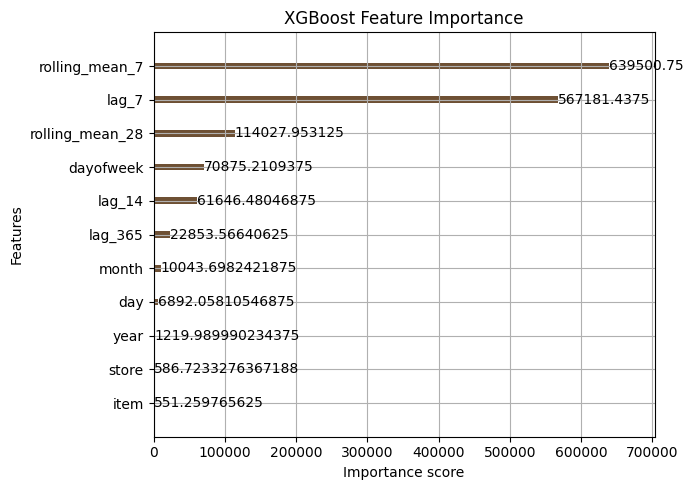

In [27]:
# feature importance
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
plot_importance(model_xgb, ax=ax, importance_type='gain', color='#6E5034')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()